# ROC curve

In [1]:
# In case of problems with importing libraries
# Load scipy-stack/2023a then re-open notebook and restart kernel
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

## Define functions

In [2]:
# Calculating true positive rate & false positive rate
def get_rates(hist_sig, hist_bkg):

    tpr_values, fpr_values = [], []
    nbins = hist_sig.shape[0]
    
    for bin_i in range(nbins):
        tp = np.sum(hist_sig[bin_i:]) # Sensitivity
        fn = np.sum(hist_sig[0:bin_i]) # Type 2 error - Rejecting a correct alt' hypothesis. The right index isn't included
        fp = np.sum(hist_bkg[bin_i:]) # Type 1 error - Rejecting a correct null hypothesis
        tn = np.sum(hist_bkg[0:bin_i]) # Specificity

        tpr = tp/(tp+fn) # True positive rate
        fpr = fp/(fp+tn) # False positive rate = 1 - Specificity = 1 - tn/(tn+fp)
        
        tpr_values.append(tpr)
        fpr_values.append(fpr)

    return fpr_values, tpr_values


In [3]:
def area_trapezoidal(x, y):
    """Calculate the area under the function given by the coordinates (x,y),
    using the trapezoidal rule."""
    # Sorting the coordinates according to their x values
    sort_order = np.argsort(x)
    x = np.array(x)[sort_order]
    y = np.array(y)[sort_order]

    # Calculating the area
    area = 0.0
    for i in range(0, len(x)-1):
        area += (x[i+1] - x[i]) * (y[i+1] + y[i]) / 2

    return area

In [4]:
# Get histogram and roc curve
def get_plots(files, tag='plot', title='', output_dir='.', show=True):
    
    path = Path(files['ztrue_bkg_file'])
    if path.suffix == '.npy':
        # Background only
        ztrue_bkg = np.load(files['ztrue_bkg_file'], allow_pickle=True)
        zpred_bkg = np.load(files['zpred_bkg_file'], allow_pickle=True)
        # Background + Signal
        ztrue_sig = np.load(files['ztrue_sig_file'], allow_pickle=True)
        zpred_sig = np.load(files['zpred_sig_file'], allow_pickle=True)
    if path.suffix == '.csv':
        remove_NaN = lambda row : row[np.isfinite(row)]
        # Background only
        ztrue_bkg = np.genfromtxt(files['ztrue_bkg_file'], delimiter=',', comments='#')
        zpred_bkg = np.genfromtxt(files['zpred_bkg_file'], delimiter=',', comments='#')
        # Background + Signal
        ztrue_sig = np.genfromtxt(files['ztrue_sig_file'], delimiter=',', comments='#')
        zpred_sig = np.genfromtxt(files['zpred_sig_file'], delimiter=',', comments='#')
                        
        ztrue_bkg = np.array([remove_NaN(row) for row in ztrue_bkg], dtype=object)
        zpred_bkg = np.array([remove_NaN(row) for row in zpred_bkg], dtype=object)
        ztrue_sig = np.array([remove_NaN(row) for row in ztrue_sig], dtype=object)
        zpred_sig = np.array([remove_NaN(row) for row in zpred_sig], dtype=object)

    
    print(ztrue_sig.shape, ztrue_bkg.shape)
    print(zpred_sig.shape, zpred_bkg.shape)
    
    n_hists = zpred_sig.shape[0]
    # print(f'Total of {n_hists} histograms')

    ztrue_bkg_max = np.array([np.amax(ztrue_bkg[i]) for i in range(n_hists)])
    zpred_bkg_max = np.array([np.amax(zpred_bkg[i]) for i in range(n_hists)])
    
    ztrue_sig_max = np.array([np.amax(ztrue_sig[i]) for i in range(n_hists)])
    zpred_sig_max = np.array([np.amax(zpred_sig[i]) for i in range(n_hists)])
    
    zmax = np.max([np.max(x) for x in [ztrue_bkg_max, zpred_bkg_max, ztrue_bkg_max, zpred_sig_max]])
    binning = np.linspace(0, zmax, num=101, endpoint=True)
    
    hist_true_bkg, _ = np.histogram(ztrue_bkg_max, bins=binning)
    hist_pred_bkg, _ = np.histogram(zpred_bkg_max, bins=binning)
    
    hist_true_sig, _ = np.histogram(ztrue_sig_max, bins=binning)
    hist_pred_sig, _ = np.histogram(zpred_sig_max, bins=binning)
    
    fpr_true, tpr_true = get_rates(hist_true_sig, hist_true_bkg)
    fpr_pred, tpr_pred = get_rates(hist_pred_sig, hist_pred_bkg)
    
    # Calculating the area under the ROC curves
    # The arguments of area_trapezoidal() are coordinates (x,y)
    auc_true = area_trapezoidal(fpr_true, tpr_true) 
    auc_pred = area_trapezoidal(fpr_pred, tpr_pred)

    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Histograms plot
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), dpi=200)
    
    ax.hist(ztrue_bkg_max, binning,
            histtype='step', linestyle='solid', color='tab:blue', label='$N_{true} = B$')
    ax.hist(zpred_bkg_max, binning,
            histtype='step', linestyle='dashed', color='tab:blue', label='$N_{pred} = B$')
    ax.hist(ztrue_sig_max, binning,
            histtype='step', linestyle='solid', color='tab:orange', label='$N_{true} = B + S$')
    ax.hist(zpred_sig_max, binning,
            histtype='step', linestyle='dashed', color='tab:orange', label='$N_{pred} = B + S$')
    
    ax.set_title(title)
    ax.set_ylabel('Entries', loc='top')
    ax.set_xlabel(r'$Z_{max}$', loc='right')
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
    ax.tick_params(axis='y', which='both', direction='in', left=True, right=True)
    ax.tick_params(which='major', axis='both')#, length=12)
    ax.tick_params(which='minor', axis='both')#, length=8)
    ax.legend(loc='upper right', frameon=False)
    
    if show: plt.show()
    
    output = f'{output_dir}/{tag}_histograms.png'
    fig.savefig(output, bbox_inches='tight')
    print(f'Saved {output}')
    plt.close(fig)

    # ROC curve
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), dpi=200)

    ax.scatter(fpr_true, tpr_true, color='tab:blue', label=f'True (AUC = {auc_true:.3f})',
              marker='.', linestyle='-')
    ax.scatter(fpr_pred, tpr_pred, color='tab:orange', label=f'Predicted (AUC = {auc_pred:.3f})',
              marker='.', linestyle='-')
    
    xmin = np.min((np.min(fpr_pred), np.min(fpr_true)))
    xmax = np.max((np.max(fpr_pred), np.max(fpr_true)))
    
    ax.plot(np.arange(xmin,xmax,0.01), np.arange(xmin,xmax,0.01),
            color='black', linestyle='--', linewidth=0.7)
    
    ax.set_title(title)
    ax.set_ylabel('True positive rate', loc='top')
    ax.set_xlabel('False positive rate', loc='right')
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
    ax.tick_params(axis='y', which='both', direction='in', left=True, right=True)
    ax.tick_params(which='major', axis='both')#, length=12)
    ax.tick_params(which='minor', axis='both')#, length=8)
    ax.legend(loc='lower right', frameon=False)
    
    if show: plt.show()
    
    output = f'{output_dir}/{tag}_roc_curve.png'
    fig.savefig(output, bbox_inches='tight')
    print(f'Saved {output}')
    plt.close(fig)
    

## Running

(116140,) (116140,)
(116140,) (116140,)


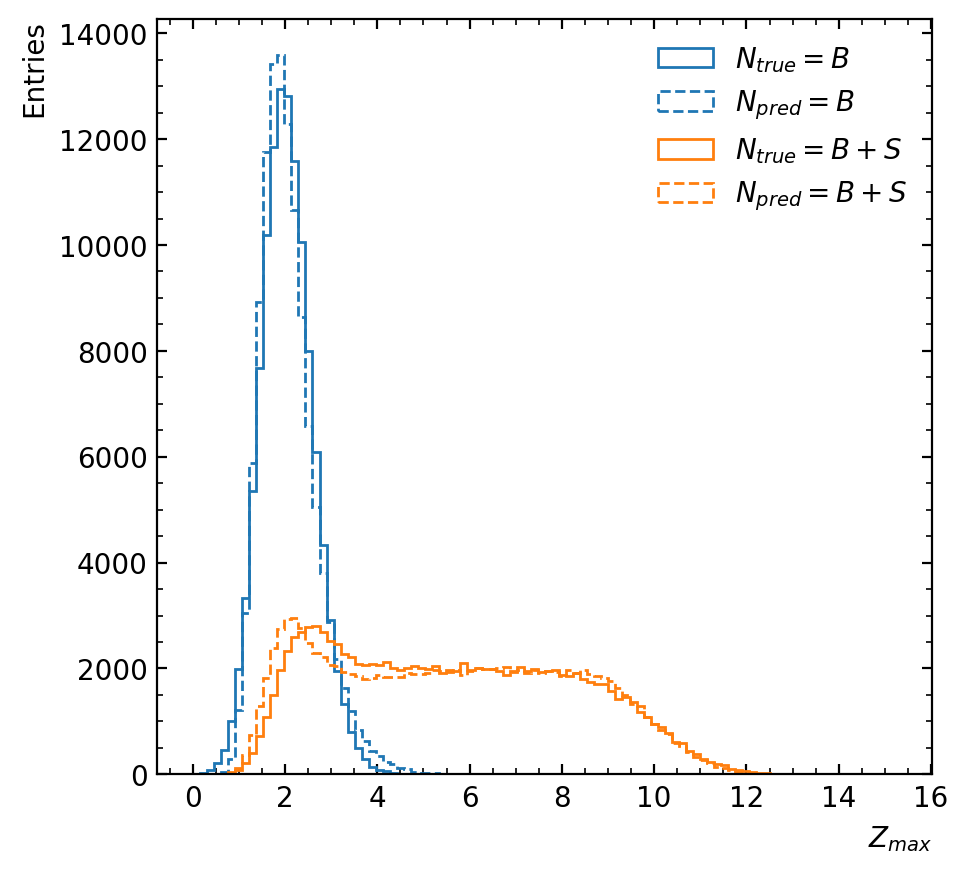

Saved ../predictions/DMfunc_1M_width1_percent1_nomassT/DMfunc_1M_width1_percent1_nomassT_histograms.png


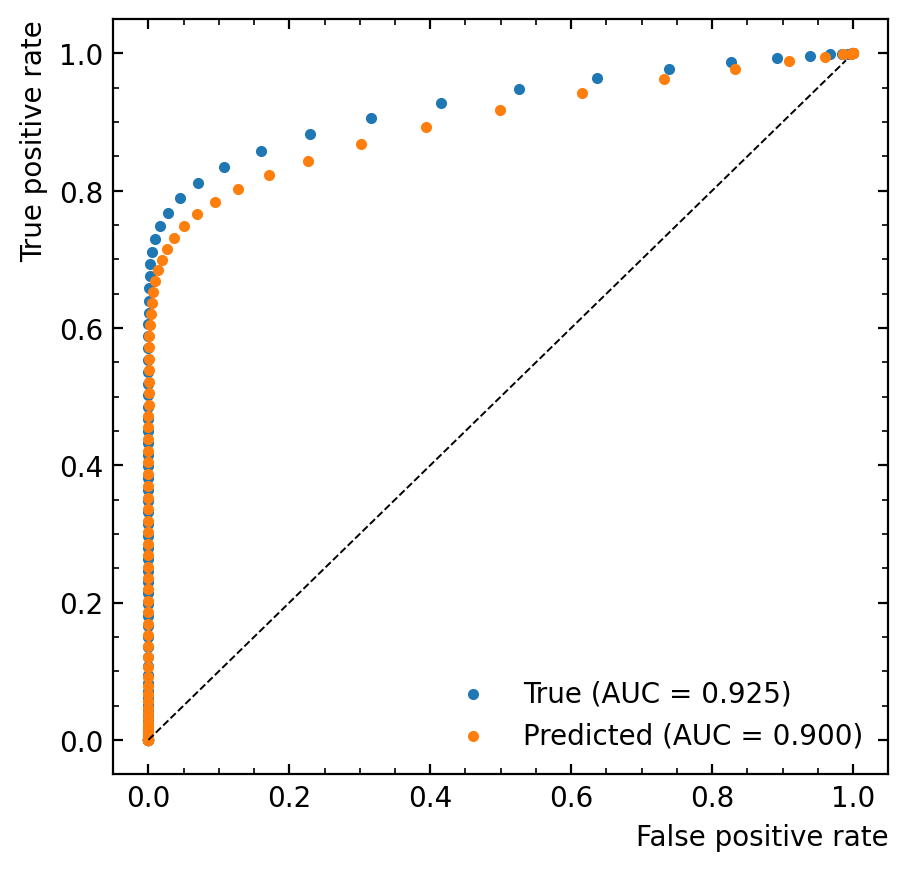

Saved ../predictions/DMfunc_1M_width1_percent1_nomassT/DMfunc_1M_width1_percent1_nomassT_roc_curve.png
Finished!


In [6]:
# Set variables
model = 'DMfunc_1M_width1_percent1_nomassT'
datasets = {'bkg_sample':'/project/def-arguinj/bruna/DDP_data/testing_sample_DMfunc_nomassT_seed_3_signal_width_1.0_percent_with_signal_0.0',
            'sig_sample':'/project/def-arguinj/bruna/DDP_data/testing_sample_DMfunc_nomassT_seed_3_signal_width_1.0_percent_with_signal_1.0',
            'bkg_prediction':'../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_DMfunc_bkg',
            'sig_prediction':'../predictions/prediction_DMfunc_1M_width1_percent1_nomassT_to_DMfunc_sig'
            }

# Get performance plots
title = '' # f'{model} to {dataset}'
output_dir = f'../predictions/{model}'
files = {
    'ztrue_bkg_file' : f'{datasets["bkg_sample"]}/Z.csv',
    'ztrue_sig_file' : f'{datasets["sig_sample"]}/Z.csv',
    'zpred_bkg_file' : f'{datasets["bkg_prediction"]}/pred_z.csv',
    'zpred_sig_file' : f'{datasets["sig_prediction"]}/pred_z.csv'
}
get_plots(files, model, title, output_dir, show=True)
print('Finished!')